# FORS 

In [1]:
# If needed (uncomment):
# !pip install diffusers torch torchvision torchmetrics accelerate tqdm


In [ ]:
import os
import time
from collections import defaultdict
from contextlib import nullcontext
from tqdm import tqdm
# from numba import cuda

import torch
import numpy as np
import matplotlib.pyplot as plt

from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from fors_sampler import FORSSampler, FORSConfig

from tqdm import tqdm

In [3]:
import os
import time
from collections import defaultdict
from contextlib import nullcontext

import torch
import numpy as np
import matplotlib.pyplot as plt

from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from fors_sampler import FORSSampler, FORSConfig
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_grad_enabled(False)

# Speed knobs
fast_mode = False
use_amp = (device == "cuda")

if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

model_id = "google/ddpm-celebahq-256"

# Default settings (fast_mode overrides below)
batch_size = 16
num_images = 1000
num_real = 2000
step_count = 100
fid_feature = 2048

if fast_mode:
    batch_size = 16
    num_images = 128
    num_real = 256
    step_count = 100
    fid_feature = 64

# FID requires at least 2 samples in each distribution
num_images = max(num_images, 2)
num_real = max(num_real, 2)

seed = 1234
torch.manual_seed(seed)

cache_dir = "./fid_cache"
os.makedirs(cache_dir, exist_ok=True)

def autocast_ctx():
    if use_amp:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


In [4]:
# need to modify so we have extremely high alpha and value at the end of the schedule,
# so that we can test the acceptance probability of the last few steps
# print(ddpm_sched)

In [5]:
unet = UNet2DModel.from_pretrained(model_id).to(device)
ddpm_sched = DDPMScheduler.from_pretrained(model_id, num_train_timesteps=step_count+1)
ddim_sched = DDIMScheduler.from_pretrained(model_id, num_train_timesteps=step_count+1)
# fors_sched = DDPMScheduler(beta_end=0.002, beta_start=0.00001, num_train_timesteps=step_count+1)
fors_sched = ddpm_sched

fors = FORSSampler(
    model=unet,
    scheduler=fors_sched,
    config=FORSConfig(B=1.0, max_resample=20),
    device=device,
)

in_channels = unet.config.in_channels
sample_size = unet.config.sample_size
if isinstance(sample_size, int):
    height = width = sample_size
else:
    height, width = sample_size


/home/kevin/anaconda3/envs/311/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [6]:
def sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

@torch.no_grad()
def sample_with_scheduler(unet, scheduler, num_inference_steps, batch_size, generator=None, eta=0.0):
    scheduler.set_timesteps(num_inference_steps)
    init_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
    x = torch.randn(
        (batch_size, in_channels, height, width),
        device=device,
        generator=generator,
    ) * init_sigma

    with autocast_ctx():
        for t in scheduler.timesteps:
            t_int = int(t)
            x_in = scheduler.scale_model_input(x, t_int)
            t_tensor = torch.full((x.shape[0],), t_int, device=device, dtype=torch.long)
            eps = unet(x_in, t_tensor).sample

            step_kwargs = {"generator": generator}
            if isinstance(scheduler, DDIMScheduler):
                step_kwargs["eta"] = eta
            x = scheduler.step(eps, t_int, x, **step_kwargs).prev_sample
    return x

def to_01(x):
    return (x.clamp(-1, 1) + 1) / 2


In [7]:
# CelebA real images (cached stats)
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((height, width)),
    transforms.ToTensor(),
])

real_ds = datasets.CelebA(
    root="./data",
    split="test",
    download=True,
    transform=transform,
)

num_workers = min(8, (os.cpu_count() or 2) // 2)
real_loader = DataLoader(
    real_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)

def add_real_images(fid_metric, n_real):
    count = 0
    for x, _ in real_loader:
        x = x.to(device, non_blocking=True)
        fid_metric.update(x, real=True)
        count += x.shape[0]
        if count >= n_real:
            break

def real_stats_cache_path():
    return os.path.join(
        cache_dir,
        f"celeba_real_stats_f{fid_feature}_n{num_real}_{height}x{width}.pt",
    )


def _state_num_samples(state, key):
    v = state.get(key, None)
    if v is None:
        return 0
    if torch.is_tensor(v):
        return int(v.item())
    return int(v)



def _metric_num_samples(metric, key):
    v = getattr(metric, key, None)
    if v is None:
        return 0
    if torch.is_tensor(v):
        return int(v.item())
    return int(v)


def load_or_compute_real_stats():
    path = real_stats_cache_path()
    if os.path.exists(path):
        state = torch.load(path, map_location="cpu")
        if _state_num_samples(state, "real_features_num_samples") >= 2:
            return state
        # stale/invalid cache

    fid = FrechetInceptionDistance(feature=fid_feature, normalize=True).to(device)
    add_real_images(fid, num_real)
    state = {k: v.cpu() for k, v in fid.state_dict().items()}
    torch.save(state, path)
    return state

real_state = load_or_compute_real_stats()


In [8]:
def init_fid_metrics(step_count):
    fids = {}
    for k in range(1, step_count + 1):
        fid = FrechetInceptionDistance(feature=fid_feature, normalize=True).to(device)
        fid.load_state_dict(real_state)
        if _metric_num_samples(fid, "real_features_num_samples") < 2:
            add_real_images(fid, num_real)
        fids[k] = fid
    return fids

def init_results_csv(path):
    with open(path, "w") as f:
        f.write("step,fid,time,img_per_sec,step_per_sec,sec_per_step\n")

def append_results_csv(path, step, fid_score, t_sample, img_per_sec, step_per_sec, sec_per_step):
    with open(path, "a") as f:
        f.write(
            f"{step},{fid_score:.6f},{t_sample:.6f},{img_per_sec:.6f},{step_per_sec:.6f},{sec_per_step:.6f}\n"
        )

@torch.no_grad()
def sample_stepwise_ddpm(unet, scheduler, batch_size, fid_map, generator=None, eta=0.0):
    # Assume scheduler.set_timesteps(...) already called outside
    init_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
    x = torch.randn(
        (batch_size, in_channels, height, width),
        device=device,
        generator=generator,
    ) * init_sigma

    step_times = {k: 0.0 for k in range(1, len(scheduler.timesteps) + 1)}
    elapsed = 0.0
    with autocast_ctx():
        for i, t in enumerate(scheduler.timesteps, start=1):
            sync()
            t0 = time.perf_counter()
            t_int = int(t)
            x_in = scheduler.scale_model_input(x, t_int)
            t_tensor = torch.full((x.shape[0],), t_int, device=device, dtype=torch.long)
            eps = unet(x_in, t_tensor).sample

            step_kwargs = {"generator": generator}
            if isinstance(scheduler, DDIMScheduler):
                step_kwargs["eta"] = eta
            x = scheduler.step(eps, t_int, x, **step_kwargs).prev_sample
            sync()
            elapsed += time.perf_counter() - t0

            step_times[i] += elapsed
            # FID update after timing; next step sync() prevents overlap
            fid_map[i].update(to_01(x), real=False)
    return step_times

@torch.no_grad()
def sample_stepwise_fors(fors_sampler, timesteps, sigma_start, batch_size, fid_map, generator=None):
    x = torch.randn(
        (batch_size, in_channels, height, width),
        device=device,
        generator=generator,
        dtype=fors_sampler.alphas_cumprod.dtype,
    ) * sigma_start

    step_times = {k: 0.0 for k in range(1, len(timesteps))}
    elapsed = 0.0
    with autocast_ctx():
        for i in range(len(timesteps) - 1):
            sync()
            t0 = time.perf_counter()
            t_cur = int(timesteps[i])
            t_prev = int(timesteps[i + 1])
            x = fors_sampler._fors_step(x, t_cur, t_prev)
            sync()
            elapsed += time.perf_counter() - t0

            step_idx = i + 1
            step_times[step_idx] += elapsed
            fid_map[step_idx].update(to_01(x), real=False)
    return step_times


In [ ]:
results = defaultdict(lambda: defaultdict(list))

step_indices = list(range(1, step_count + 1))
results_dir = os.path.join(cache_dir, "results")
os.makedirs(results_dir, exist_ok=True)

for name in ["fors", "ddpm", "ddim"]:
    fid_map = init_fid_metrics(step_count)
    time_map = {k: 0.0 for k in step_indices}

    if name == "ddpm":
        ddpm_sched.set_timesteps(step_count)
    elif name == "ddim":
        ddim_sched.set_timesteps(step_count)
    else:
        # For FORS, use one extra timestep so we get exactly step_count transitions
        fors.set_timesteps(step_count + 1)
        fors_timesteps = fors.timesteps
        t_start = int(fors_timesteps[0])
        sigma_start = torch.sqrt(1.0 - fors.alphas_cumprod[t_start])

    count = 0
    batch_idx = 0
    pbar = tqdm(total=num_images, desc=f"{name} images")
    while count < num_images:
        bs = min(batch_size, num_images - count)
        gen = torch.Generator(device=device).manual_seed(seed + batch_idx)
        if name == "ddpm":
            step_times = sample_stepwise_ddpm(unet, ddpm_sched, bs, fid_map, generator=gen)
        elif name == "ddim":
            step_times = sample_stepwise_ddpm(unet, ddim_sched, bs, fid_map, generator=gen, eta=0.0)
        else:
            step_times = sample_stepwise_fors(fors, fors_timesteps, sigma_start, bs, fid_map, generator=gen)
        for k in step_indices:
            time_map[k] += step_times[k]
        count += bs
        batch_idx += 1
        pbar.update(bs)
    pbar.close()

    csv_path = os.path.join(results_dir, f"{name}_steps{step_count}_n{num_images}_f{fid_feature}.csv")
    init_results_csv(csv_path)

    for k in step_indices:
        fid = fid_map[k]
        if _metric_num_samples(fid, "fake_features_num_samples") < 2:
            raise RuntimeError("Not enough fake samples to compute FID. Increase num_images.")
        fid_score = float(fid.compute().cpu())
        t_sample = time_map[k]

        img_per_sec = num_images / max(t_sample, 1e-9)
        step_per_sec = (num_images * k) / max(t_sample, 1e-9)
        sec_per_step = t_sample / max(num_images * k, 1e-9)

        results[name]["fid"].append(fid_score)
        results[name]["time"].append(t_sample)
        results[name]["img_per_sec"].append(img_per_sec)
        results[name]["step_per_sec"].append(step_per_sec)
        results[name]["sec_per_step"].append(sec_per_step)

        append_results_csv(csv_path, k, fid_score, t_sample, img_per_sec, step_per_sec, sec_per_step)

        print(
            f"steps={k:>3}  sampler={name:>4}  FID={fid_score:>7.2f}  "
            f"time={t_sample:>7.2f}s  imgs/s={img_per_sec:>7.2f}  step/s={step_per_sec:>9.2f}"
        )


In [ ]:
# import pandas as pd
# if 'results' not in locals() and 'results' not in globals():
#     results = {k : pd.read_csv('fid_cache/results/'+k+'_steps100_n128_f64.csv', index_col=0) 
#                for k in ["fors", "ddpm", "ddim"]}

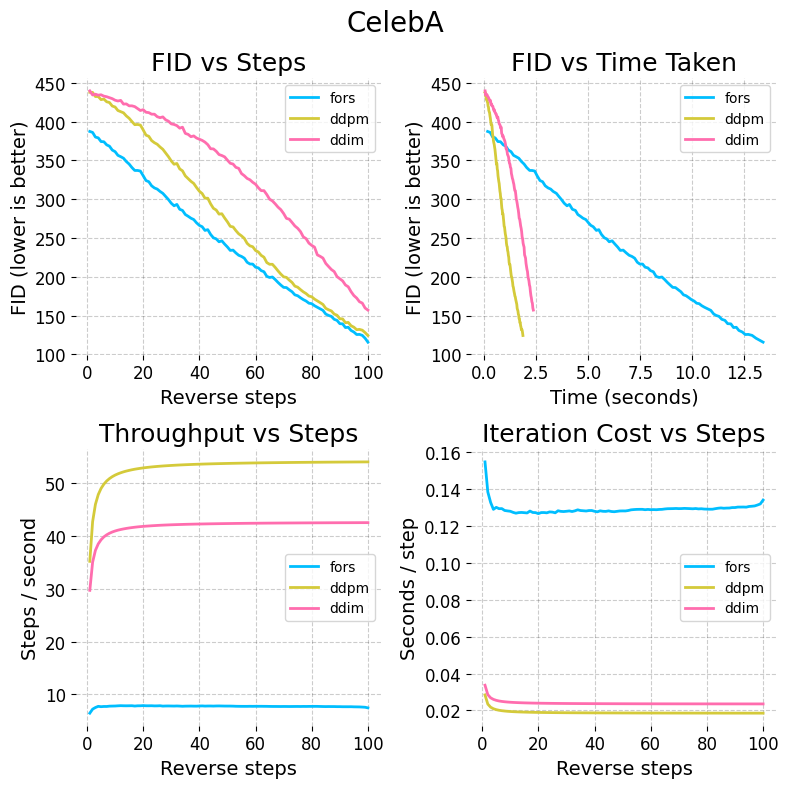

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8), nrows=2, ncols=2)

for name, scores in results.items():
    ax[0,0].plot(step_indices, scores["fid"], label=name)
    ax[0,1].plot(np.array(step_indices) * scores["sec_per_step"], scores["fid"], label=name)
    ax[1,0].plot(step_indices, scores["step_per_sec"], label=name)
    ax[1,1].plot(step_indices, scores["sec_per_step"], label=name)

ax[0,0].set_xlabel("Reverse steps")
ax[0,0].set_ylabel("FID (lower is better)")
ax[0,0].set_title("FID vs Steps")
ax[0,1].set_xlabel("Time (seconds)")
ax[0,1].set_ylabel("FID (lower is better)")
ax[0,1].set_title("FID vs Time Taken")
ax[1,0].set_xlabel("Reverse steps")
ax[1,0].set_ylabel("Steps / second")
ax[1,0].set_title("Throughput vs Steps")
ax[1,1].set_xlabel("Reverse steps")
ax[1,1].set_ylabel("Seconds / step")
ax[1,1].set_title("Iteration Cost vs Steps")
fig.suptitle('CelebA', fontsize=20)
ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()
plt.tight_layout()
plt.savefig('figs/celeba_results.png')

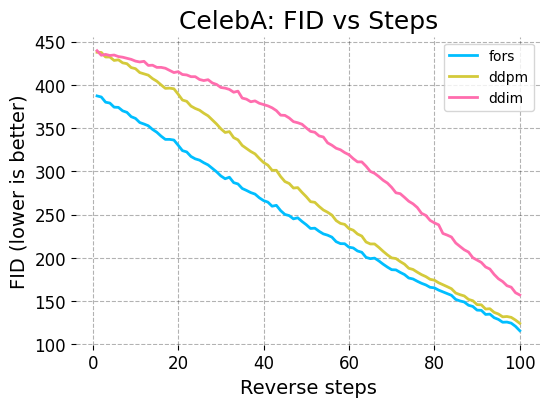

In [ ]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(step_indices, scores["fid"], label=name)

plt.xlabel("Reverse steps")
plt.ylabel("FID (lower is better)")
plt.title("CelebA: FID vs Steps")
plt.legend()
plt.show()


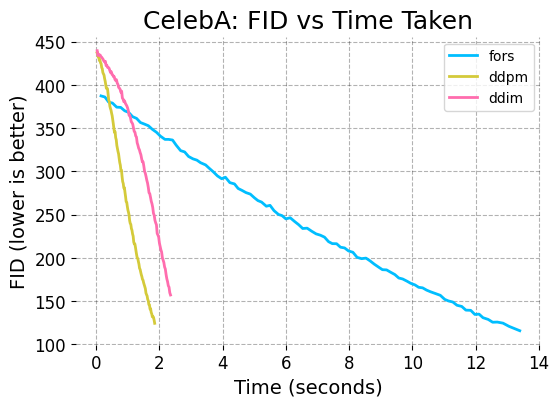

In [ ]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(np.array(step_indices) * scores["sec_per_step"], scores["fid"], label=name)

plt.xlabel("Time (seconds)")
plt.ylabel("FID (lower is better)")
plt.title("CelebA: FID vs Time Taken")
plt.legend()
plt.show()


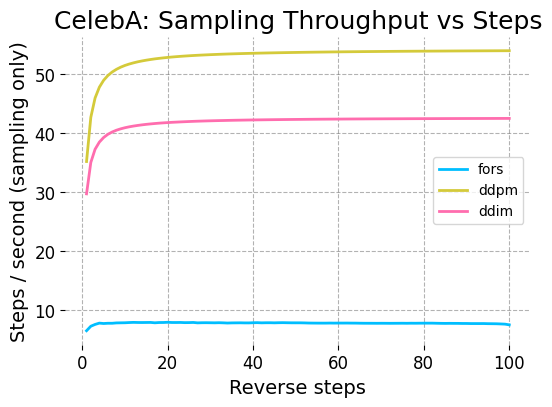

In [ ]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(step_indices, scores["step_per_sec"], label=name)

plt.xlabel("Reverse steps")
plt.ylabel("Steps / second (sampling only)")
plt.title("CelebA: Sampling Throughput vs Steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


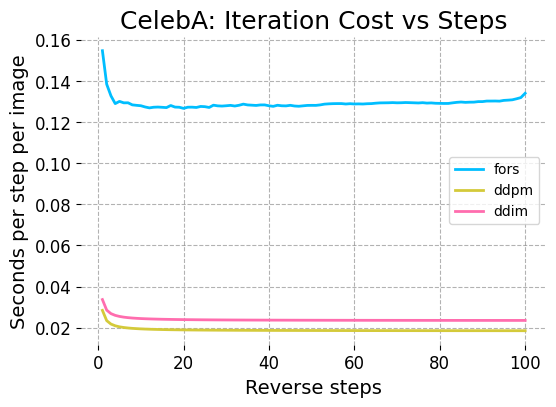

In [ ]:
plt.figure(figsize=(6, 4))
for name, scores in results.items():
    plt.plot(step_indices, scores["sec_per_step"], label=name)

plt.xlabel("Reverse steps")
plt.ylabel("Seconds per step per image")
plt.title("CelebA: Iteration Cost vs Steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
